# 07 - Model Comparison and Evaluation

This notebook compares baseline and tuned model outputs from `data/results` and creates visual summaries for cross-model evaluation.


In [1]:
from json_utils import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)




In [2]:
metrics_df = load_all_metrics()
boxplot_df = load_boxplot_stats()
feat_imp_df = load_feature_importance()

print("Metrics rows:", len(metrics_df))
display(metrics_df.sort_values(["model", "variant", "stage"]))

print("Boxplot models:", boxplot_df["model"].tolist())

print("Feature importance models:", sorted(feat_imp_df["model"].unique().tolist()))


Metrics rows: 11


,model,variant,stage,MAE,RMSE,MAPE,R2
0,ElasticNet,baseline,test,35.1281,37.3500,0.1489,-1.0476
1,ElasticNet,baseline,train,8.4328,10.3764,0.1212,0.9662
2,ElasticNet,tuned,test,4.0453,5.4991,0.0178,0.9556
3,Linear Regression,baseline,test,3.9460,5.3718,0.0174,0.9576
4,Linear Regression,baseline,train,1.6129,2.4296,0.0170,0.9981
5,Random Forest,baseline,test,43.2025,49.7932,0.1773,-2.6392
6,Random Forest,baseline,train,0.6564,1.0498,0.0067,0.9997
7,Random Forest,tuned,test,43.2589,49.8361,0.1776,-2.6454
8,SVR-linear,baseline,test,4.3317,5.9721,0.0191,0.9477
9,SVR-linear,baseline,train,1.7510,2.6564,0.0186,0.9978


Boxplot models: ['ElasticNet', 'Linear Regression', 'Random Forest', 'SVR-linear']
Feature importance models: ['ElasticNet', 'Linear Regression', 'Random Forest', 'SVR-linear']


## 1) Baseline Train vs Baseline Test (per model)


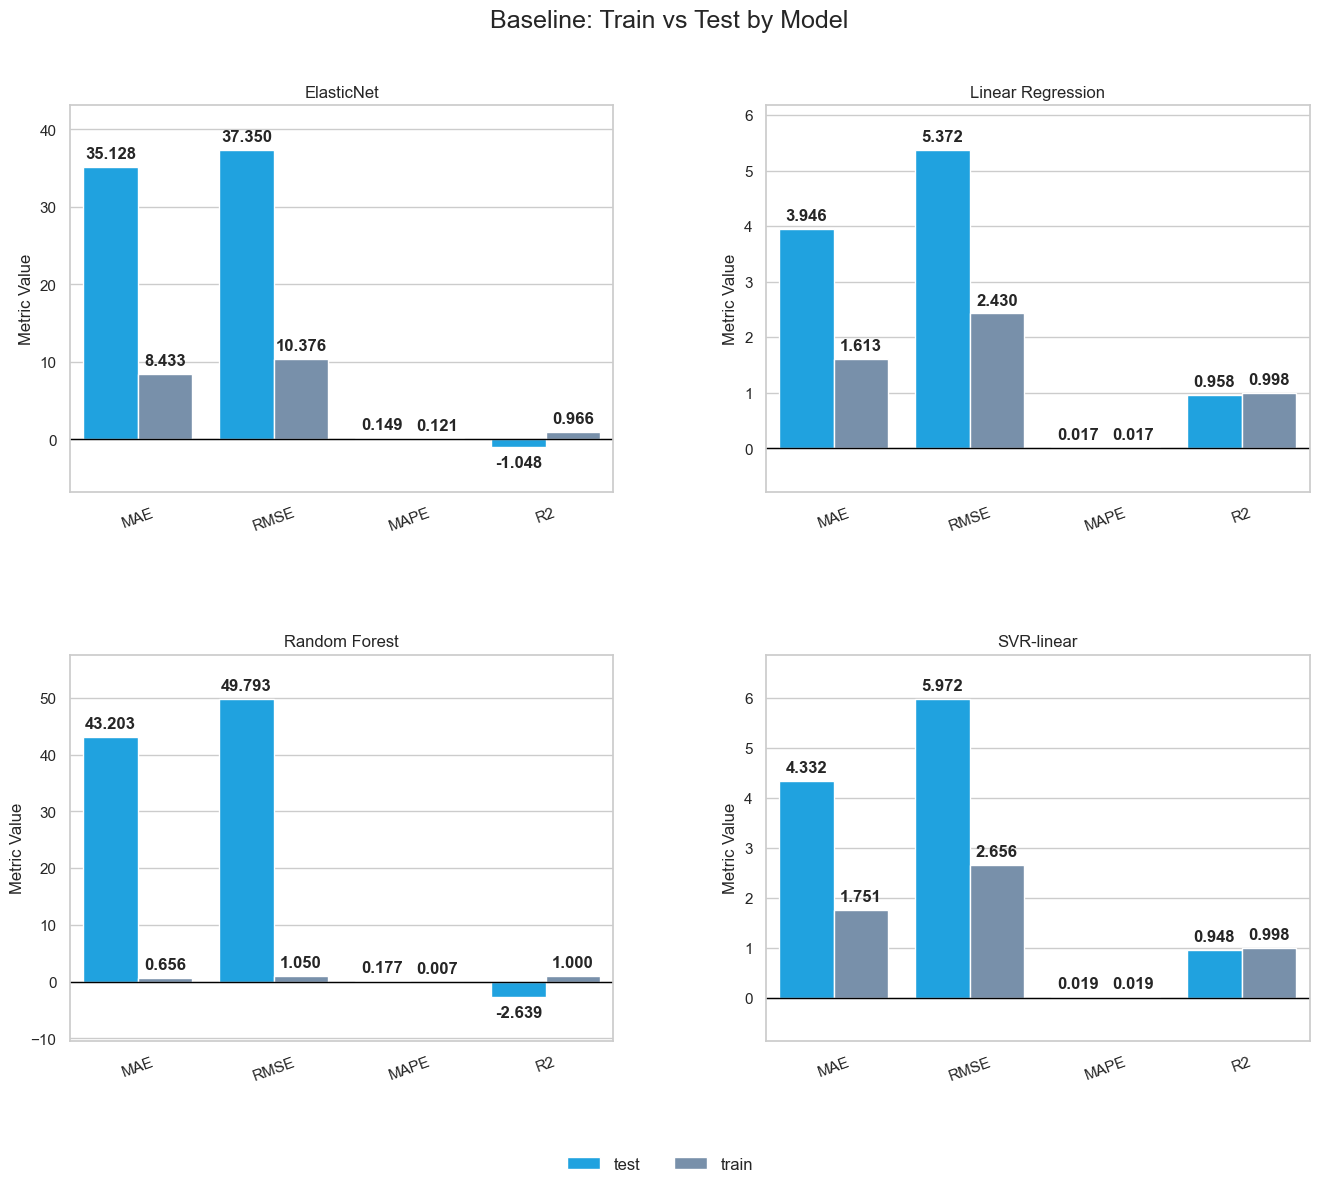

In [ ]:
baseline = metrics_df[metrics_df["variant"] == "baseline"].copy()
models = sorted(baseline["model"].unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, model in enumerate(models[:4]):
    ax = axes[i]
    sub = baseline[baseline["model"] == model]
    long_df = sub.melt(
        id_vars=["model", "variant", "stage"],
        value_vars=METRICS,
        var_name="metric",
        value_name="value"
    )

    sns.barplot(data=long_df, x="metric", y="value", hue="stage", ax=ax, palette={"train": "#2187F4", "test": "#F58518"})
    ax.axhline(0, color="black", linewidth=1)

    ax.set_title(model)
    ax.set_xlabel("")
    ax.set_ylabel("Metric Value")
    ax.tick_params(axis="x", rotation=20)

    # dynamic y padding per subplot
    y_min = np.nanmin(long_df["value"].values)
    y_max = np.nanmax(long_df["value"].values)
    pad = max((y_max - y_min) * 0.15, 0.5)
    ax.set_ylim(y_min - pad, y_max + pad)

    # callouts for grouped bars
    for p in ax.patches:
        h = p.get_height()

        # Skip placeholder/empty bars that create fake 0.000 labels
        if (not np.isfinite(h)) or abs(h) < 1e-12:
            continue

        ax.annotate(
            f"{h:.3f}",
            (p.get_x() + p.get_width() / 2, h),
            ha="center",
            va="bottom" if h >= 0 else "top",
            xytext=(0, 4 if h >= 0 else -6),
            textcoords="offset points",
            fontsize=12,
            fontweight="bold",
        )


for j in range(len(models), 4):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# bottom-center legend
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, fontsize=12)

fig.suptitle("Baseline: Train vs Test by Model", y=0.98, fontsize=18)

# extra spacing between subplots + room for legend
fig.subplots_adjust(hspace=0.42, wspace=0.28, bottom=0.12, top=0.90)

plt.show()


## 2) Baseline Test Metrics Normalized by Metric
Each metric is scaled so the max value across models is 100%.


C:\Users\yeapz\AppData\Local\Temp\ipykernel_14144\324780910.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="model", y="pct", ax=ax, palette=bar_colors)
C:\Users\yeapz\AppData\Local\Temp\ipykernel_14144\324780910.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="model", y="pct", ax=ax, palette=bar_colors)
C:\Users\yeapz\AppData\Local\Temp\ipykernel_14144\324780910.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="model", y="pct", ax=ax, palette=bar_colors)
C:\Users\yeapz\AppData\Local\Temp\ipy

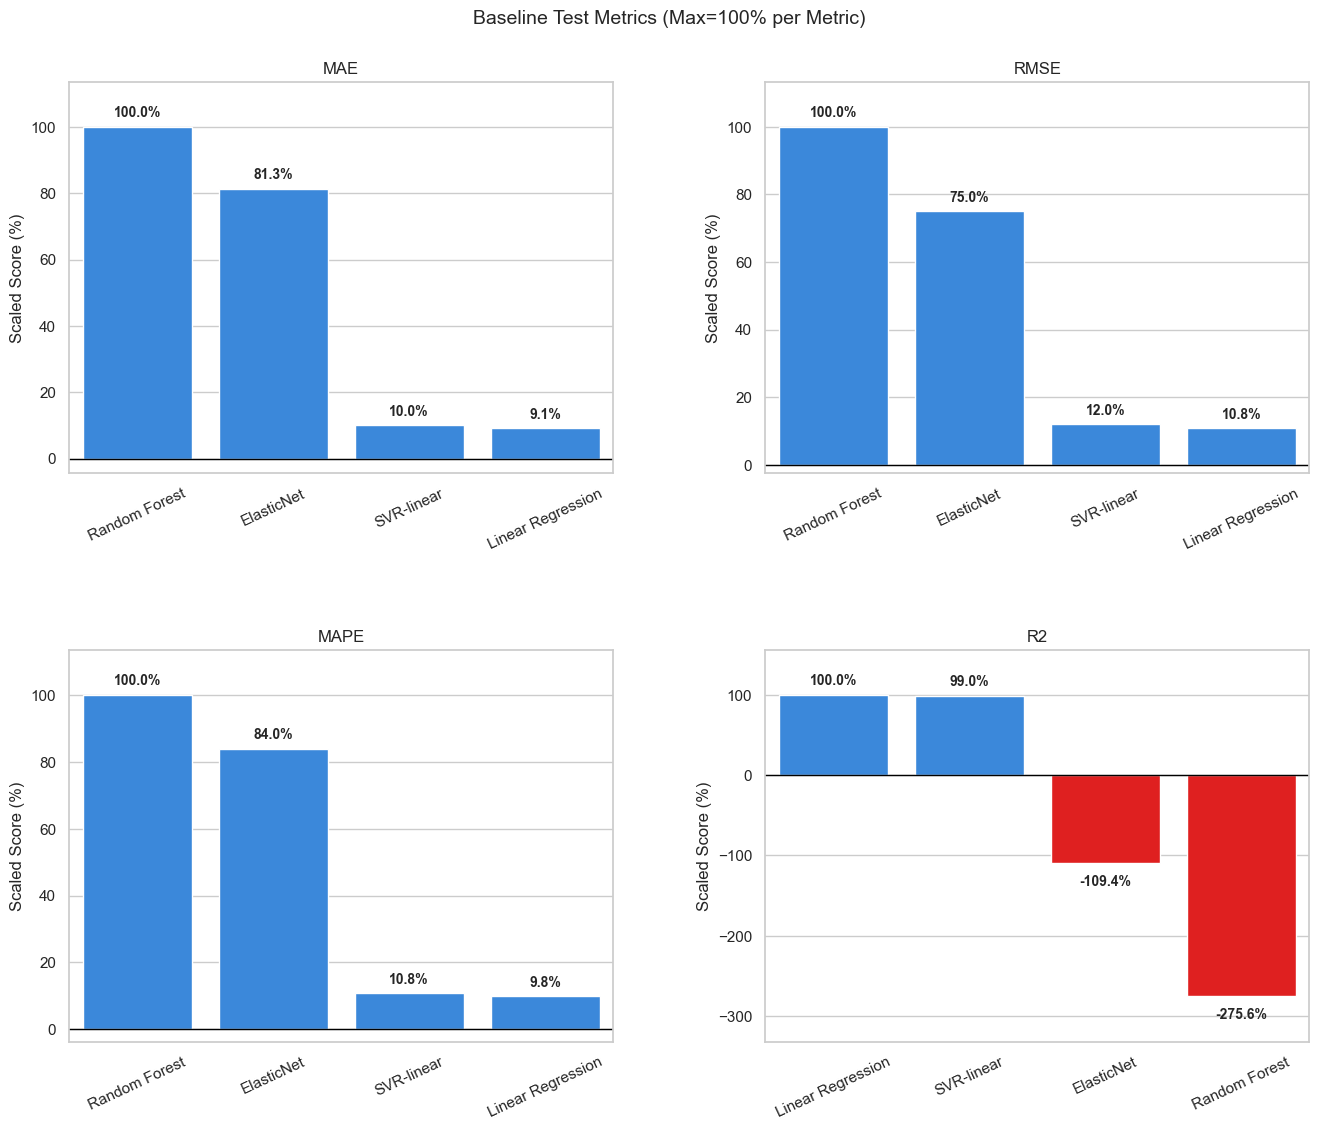

In [4]:
from matplotlib.patches import Patch

baseline_test = metrics_df.query("variant == 'baseline' and stage == 'test'").copy()

norm_rows = []
for metric in METRICS:
    max_val = baseline_test[metric].max()
    for _, r in baseline_test.iterrows():
        if pd.isna(max_val) or max_val == 0:
            pct = np.nan
        else:
            pct = (r[metric] / max_val) * 100
        norm_rows.append({"model": r["model"], "metric": metric, "pct": pct})

baseline_norm = pd.DataFrame(norm_rows)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, metric in enumerate(METRICS):
    ax = axes[i]
    sub = baseline_norm[baseline_norm["metric"] == metric].sort_values("pct", ascending=False).reset_index(drop=True)

    # color negatives red
    bar_colors = ["red" if v < 0 else "#2187F4" for v in sub["pct"]]
    sns.barplot(data=sub, x="model", y="pct", ax=ax, palette=bar_colors)

    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("Scaled Score (%)")
    ax.tick_params(axis="x", rotation=25)

    y_min = np.nanmin(sub["pct"].values)
    y_max = np.nanmax(sub["pct"].values)
    pad = max((y_max - y_min) * 0.15, 8)
    ax.set_ylim(y_min - pad, y_max + pad)

    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h):
            ax.annotate(
                f"{h:.1f}%",
                (p.get_x() + p.get_width() / 2, h),
                ha="center",
                va="bottom" if h >= 0 else "top",
                xytext=(0, 5 if h >= 0 else -8),
                textcoords="offset points",
                fontsize=10,
                fontweight="bold",
            )

fig.suptitle("Baseline Test Metrics (Max=100% per Metric)", y=0.98, fontsize=14)
fig.subplots_adjust(hspace=0.45, wspace=0.28, bottom=0.12, top=0.92)

plt.show()


## 3) Tuned vs Baseline: Percentage Improvement
For `MAE`, `RMSE`, `MAPE`: `(baseline - tuned) / baseline * 100` (error reduction)  
For `R2`: `(tuned - baseline) / abs(baseline) * 100` (relative improvement)


C:\Users\yeapz\AppData\Local\Temp\ipykernel_14144\56726153.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="metric", y="improvement_pct", ax=ax, palette=bar_colors)
C:\Users\yeapz\AppData\Local\Temp\ipykernel_14144\56726153.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="metric", y="improvement_pct", ax=ax, palette=bar_colors)
C:\Users\yeapz\AppData\Local\Temp\ipykernel_14144\56726153.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="metric", y="improvement_pct", ax=ax, palette=bar_colors)


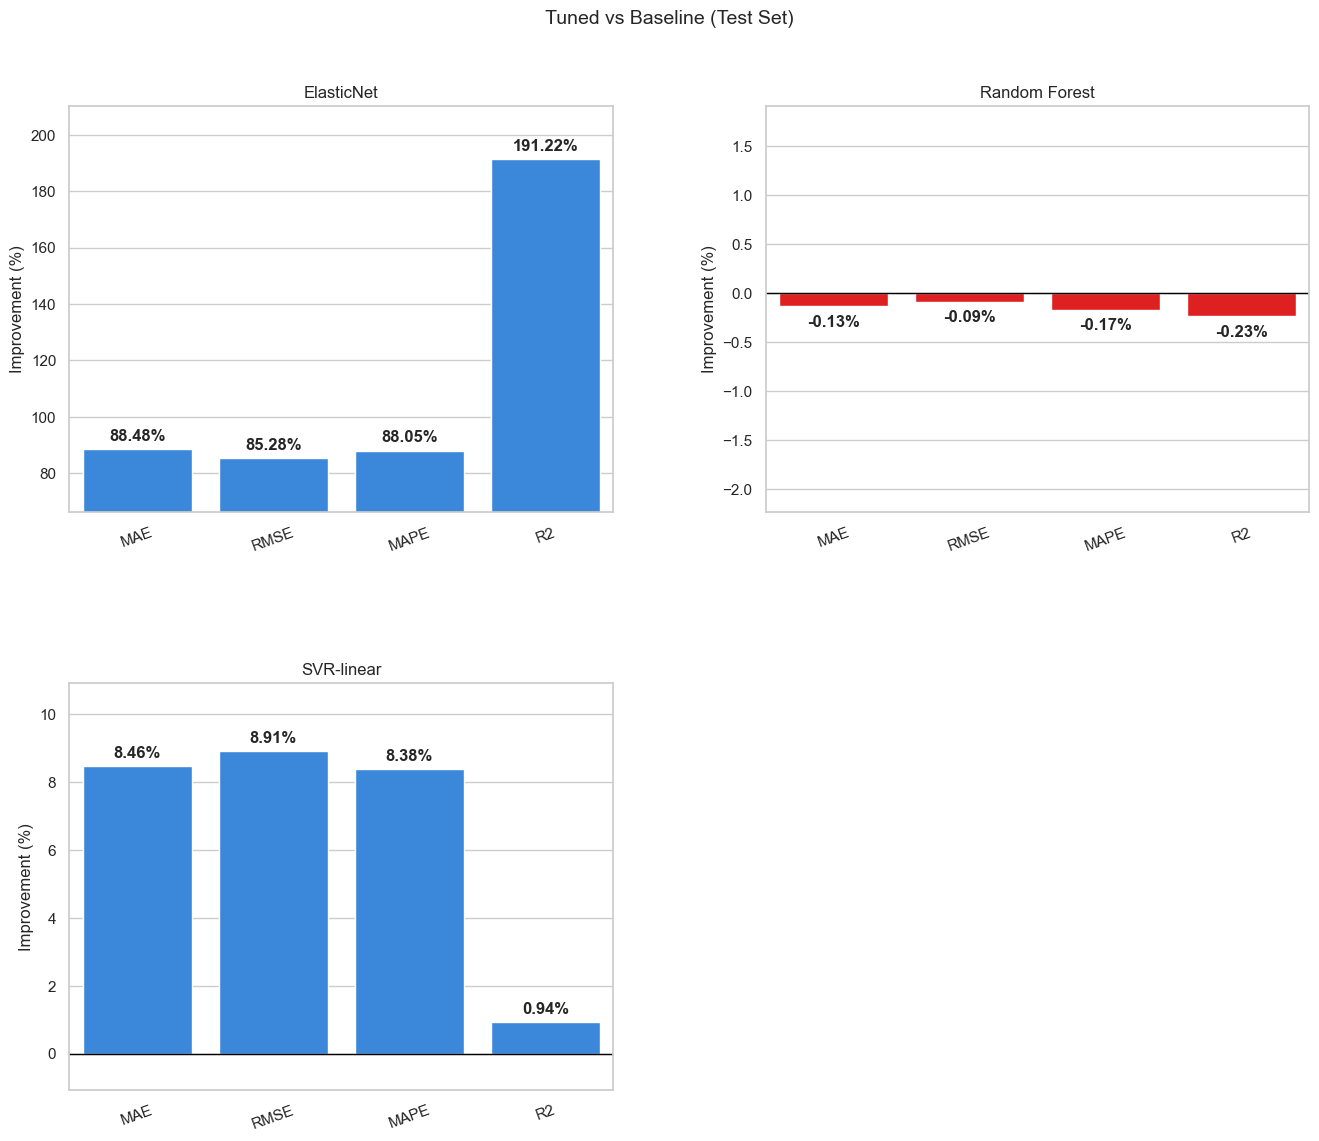

In [10]:
base_test = metrics_df.query("variant == 'baseline' and stage == 'test'").set_index("model")
tuned_test = metrics_df.query("variant == 'tuned' and stage == 'test'").set_index("model")
common_models = sorted(set(base_test.index).intersection(set(tuned_test.index)))

improve_rows = []
for model in common_models:
    for metric in METRICS:
        b = base_test.loc[model, metric]
        t = tuned_test.loc[model, metric]
        if metric in ERROR_METRICS:
            pct = np.nan if b == 0 else ((b - t) / b) * 100
        else:
            pct = np.nan if b == 0 else ((t - b) / abs(b)) * 100
        improve_rows.append({"model": model, "metric": metric, "improvement_pct": pct})

improve_df = pd.DataFrame(improve_rows)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, model in enumerate(common_models[:4]):
    ax = axes[i]
    sub = improve_df[improve_df["model"] == model].copy()

    bar_colors = ["red" if v < 0 else "#2187F4" for v in sub["improvement_pct"]]
    sns.barplot(data=sub, x="metric", y="improvement_pct", ax=ax, palette=bar_colors)
    ax.axhline(0, color="black", linewidth=1)

    ax.set_title(model)
    ax.set_xlabel("")
    ax.set_ylabel("Improvement (%)")
    ax.tick_params(axis="x", rotation=20)

    # dynamic per-plot padding
    y_min = np.nanmin(sub["improvement_pct"].values)
    y_max = np.nanmax(sub["improvement_pct"].values)
    pad = max((y_max - y_min) * 0.18, 2.0)
    ax.set_ylim(y_min - pad, y_max + pad)

    # callouts
    for p in ax.patches:
        h = p.get_height()

        # skip placeholders / zero-height artifacts
        if (not np.isfinite(h)) or abs(h) < 1e-12:
            continue

        ax.annotate(
            f"{h:.2f}%",
            (p.get_x() + p.get_width() / 2, h),
            ha="center",
            va="bottom" if h >= 0 else "top",
            xytext=(0, 4 if h >= 0 else -6),
            textcoords="offset points",
            fontsize=12,
            fontweight="bold",
        )

for j in range(len(common_models), 4):
    axes[j].axis("off")

fig.suptitle("Tuned vs Baseline (Test Set)", y=0.98, fontsize=14)

# extra space between plots
fig.subplots_adjust(hspace=0.42, wspace=0.28, top=0.90, bottom=0.08)

plt.show()


In [19]:
# Raw test metrics table: baseline vs tuned (exclude Linear Regression)
raw_compare = (
    metrics_df.query(
        "stage == 'test' and variant in ['baseline', 'tuned'] and model != 'Linear Regression'"
    )
    .pivot_table(
        index="model",
        columns="variant",
        values=METRICS,
        aggfunc="first",
    )
)

# Make columns easier to read
raw_compare.columns = [
    f"{metric} {f'({variant})' if variant == 'tuned' else ''}".strip()
    for metric, variant in raw_compare.columns
]

# Order by baseline RMSE first; fallback to tuned RMSE if needed
sort_col = "RMSE" if "RMSE" in raw_compare.columns else "RMSE (tuned)"
raw_compare = raw_compare.sort_values(sort_col, ascending=True, na_position="last")

display(raw_compare.round(4))


,MAE,MAE (tuned),MAPE,MAPE (tuned),R2,R2 (tuned),RMSE,RMSE (tuned)
model,,,,,,,,
SVR-linear,4.3317,3.9652,0.0191,0.0175,0.9477,0.9566,5.9721,5.4400
ElasticNet,35.1281,4.0453,0.1489,0.0178,-1.0476,0.9556,37.3500,5.4991
Random Forest,43.2025,43.2589,0.1773,0.1776,-2.6392,-2.6454,49.7932,49.8361


## 4) Tuned Test Metrics Normalized by Metric
Each metric is scaled so the max tuned value across models is 100%.


C:\Users\yeapz\AppData\Local\Temp\ipykernel_14144\528185748.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="model", y="pct", ax=ax, palette=bar_colors)
C:\Users\yeapz\AppData\Local\Temp\ipykernel_14144\528185748.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="model", y="pct", ax=ax, palette=bar_colors)
C:\Users\yeapz\AppData\Local\Temp\ipykernel_14144\528185748.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="model", y="pct", ax=ax, palette=bar_colors)
C:\Users\yeapz\AppData\Local\Temp\ipy

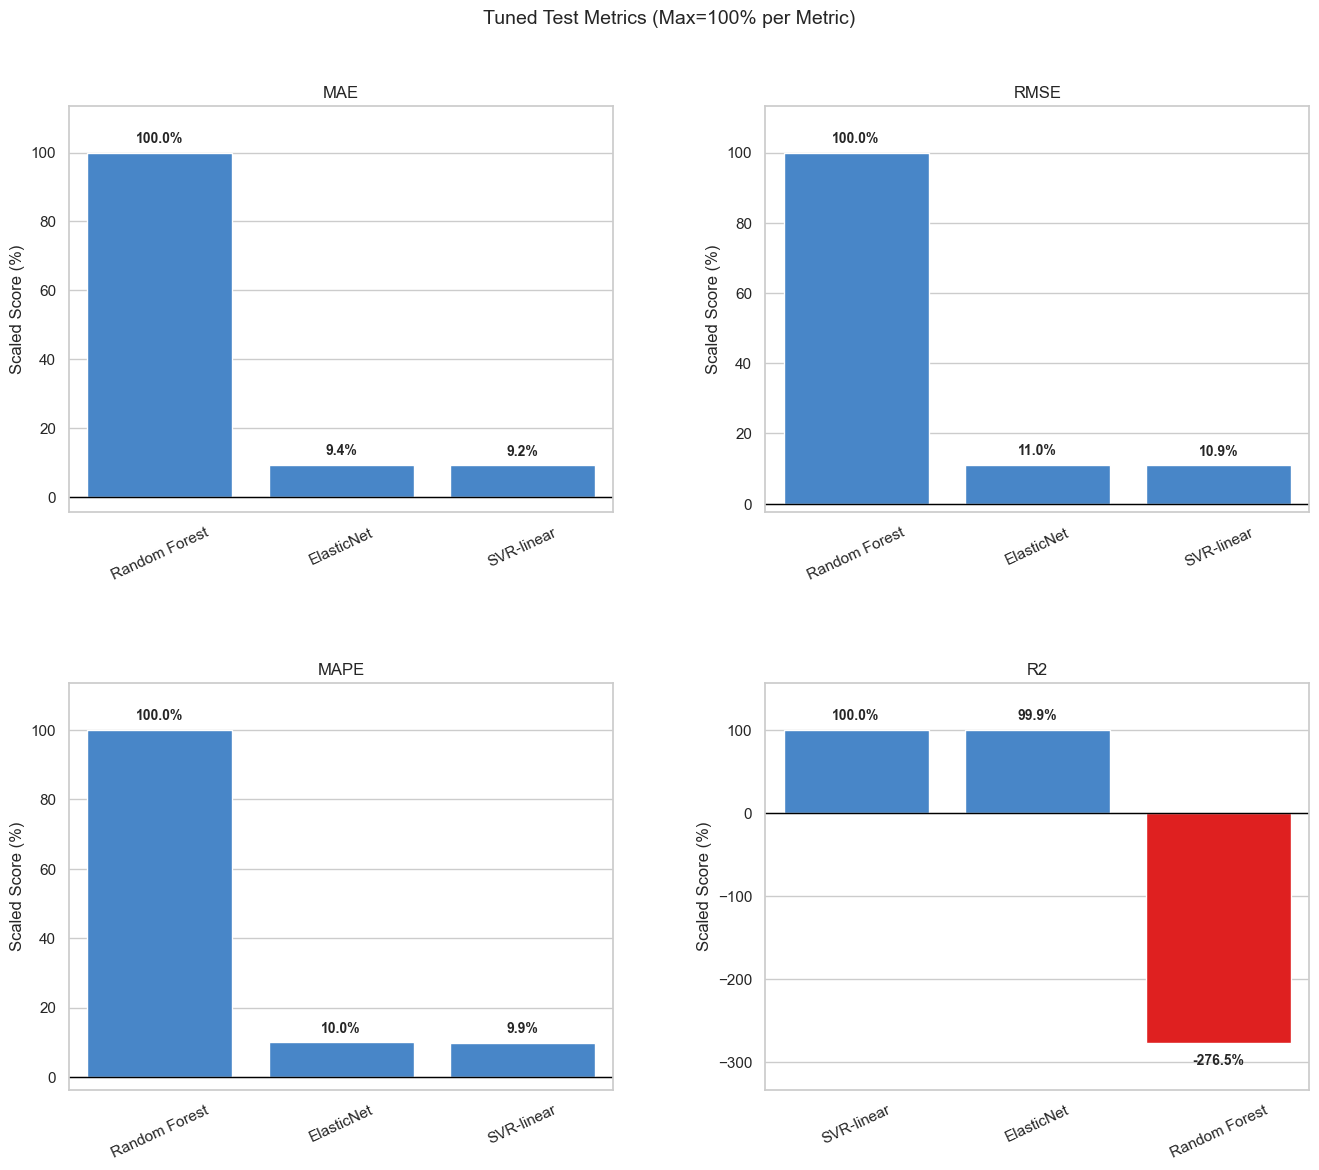

In [25]:
tuned_only = metrics_df.query("variant == 'tuned' and stage == 'test'").copy()

if tuned_only.empty:
    print("No tuned test metrics found.")
else:
    tuned_norm_rows = []
    for metric in METRICS:
        max_val = tuned_only[metric].max()
        for _, r in tuned_only.iterrows():
            if pd.isna(max_val) or max_val == 0:
                pct = np.nan
            else:
                pct = (r[metric] / max_val) * 100
            tuned_norm_rows.append({"model": r["model"], "metric": metric, "pct": pct})

    tuned_norm = pd.DataFrame(tuned_norm_rows)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for i, metric in enumerate(METRICS):
        ax = axes[i]
        sub = tuned_norm[tuned_norm["metric"] == metric].sort_values("pct", ascending=False).reset_index(drop=True)

        # color negatives red
        bar_colors = ["red" if v < 0 else "#3385DD" for v in sub["pct"]]
        sns.barplot(data=sub, x="model", y="pct", ax=ax, palette=bar_colors)

        ax.axhline(0, color="black", linewidth=1)
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.set_ylabel("Scaled Score (%)")
        ax.tick_params(axis="x", rotation=25)

        y_min = np.nanmin(sub["pct"].values)
        y_max = np.nanmax(sub["pct"].values)
        pad = max((y_max - y_min) * 0.15, 8)
        ax.set_ylim(y_min - pad, y_max + pad)

        # callouts
        for p in ax.patches:
            h = p.get_height()
            if (not np.isfinite(h)) or abs(h) < 1e-12:
                continue
            ax.annotate(
                f"{h:.1f}%",
                (p.get_x() + p.get_width() / 2, h),
                ha="center",
                va="bottom" if h >= 0 else "top",
                xytext=(0, 5 if h >= 0 else -8),
                textcoords="offset points",
                fontsize=10,
                fontweight="bold",
            )

    fig.suptitle("Tuned Test Metrics (Max=100% per Metric)", y=0.98, fontsize=14)
    fig.subplots_adjust(hspace=0.42, wspace=0.28, top=0.90, bottom=0.08)

    plt.show()


## 5) Stacked Boxplot Statistics Across Models
This uses saved boxplot summary stats (`q1`, `median`, `q3`, whiskers) and draws all models together in one graph.


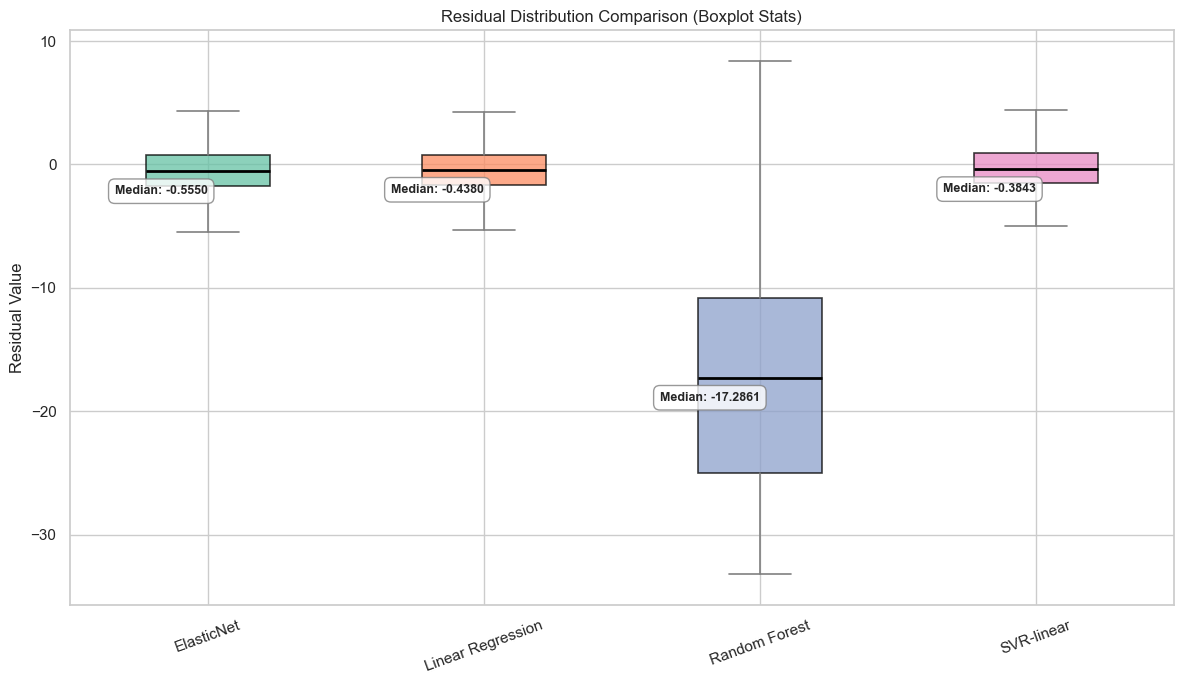

In [30]:
if boxplot_df.empty:
    print("No boxplot stats found.")
else:
    boxplot_sorted = boxplot_df.sort_values("model").reset_index(drop=True)

    box_stats = []
    for _, r in boxplot_sorted.iterrows():
        box_stats.append({
            "label": r["model"],
            "med": r["median"],
            "q1": r["q1"],
            "q3": r["q3"],
            "whislo": r["whislo"],
            "whishi": r["whishi"],
            "fliers": [],
        })

    fig, ax = plt.subplots(figsize=(12, 7))

    # draw boxplot and style each model differently
    bxp = ax.bxp(box_stats, showfliers=False, patch_artist=True)

    palette = sns.color_palette("Set2", n_colors=len(box_stats))
    for patch, color in zip(bxp["boxes"], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.2)

    for med in bxp["medians"]:
        med.set_color("black")
        med.set_linewidth(2)

    for whisk in bxp["whiskers"]:
        whisk.set_color("gray")
        whisk.set_linewidth(1.2)

    for cap in bxp["caps"]:
        cap.set_color("gray")
        cap.set_linewidth(1.2)

    # callouts for median values ("mid values")
    y_min = boxplot_sorted[["whislo", "whishi"]].min().min()
    y_max = boxplot_sorted[["whislo", "whishi"]].max().max()
    pad = max((y_max - y_min) * 0.06, 0.12)

    for i, r in boxplot_sorted.iterrows():
        x = i + 1  # bxp positions are 1-based
        y = r["median"]
        ax.annotate(
            f"Median: {y:.4f}",
            (x, y),
            ha="right",
            va="bottom" if y >= 0 else "top",
            xytext=(0, 8 if y >= 0 else -10),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8),
        )

    ax.set_title("Residual Distribution Comparison (Boxplot Stats)")
    ax.set_ylabel("Residual Value")
    ax.tick_params(axis="x", rotation=20)
    ax.set_ylim(y_min - pad, y_max + pad)

    plt.tight_layout()
    plt.show()


In [31]:
# Boxplot stats table by model
if boxplot_df.empty:
    print("No boxplot stats found.")
else:
    boxplot_table = (
        boxplot_df.sort_values("model")
        .rename(
            columns={
                "model": "Model",
                "q1": "Q1 (25%)",
                "median": "Median (50%)",
                "q3": "Q3 (75%)",
                "whislo": "Lower whisker",
                "whishi": "Upper whisker",
            }
        )
    )

    display(boxplot_table.round(4))


,Model,Q1 (25%),Median (50%),Q3 (75%),Lower whisker,Upper whisker
0,ElasticNet,-1.7253,-0.5550,0.7565,-5.4411,4.3471
1,Linear Regression,-1.6871,-0.4380,0.7331,-5.2856,4.2807
2,Random Forest,-24.9870,-17.2861,-10.8421,-33.2047,8.3654
3,SVR-linear,-1.5293,-0.3843,0.8922,-5.0135,4.4382


## 6) Top-3 Feature Importance per Model (Grouped Horizontal Bar)


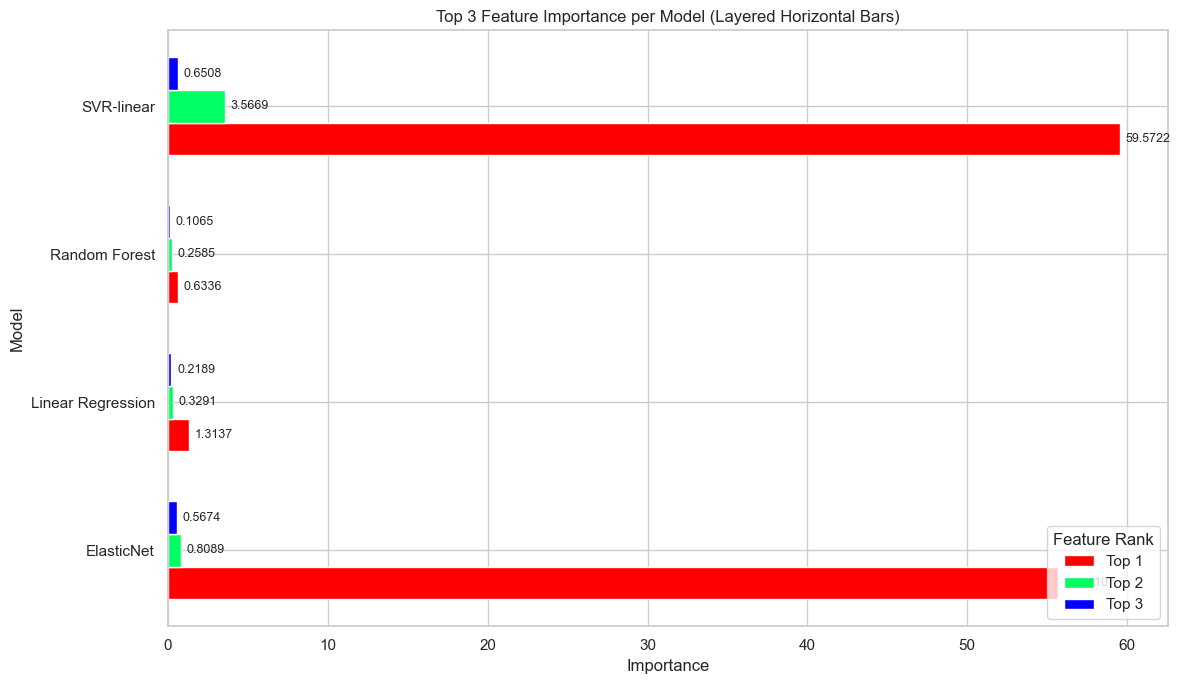

,model,rank,feature,importance
0,ElasticNet,1,adj_close_smooth,55.691031
1,ElasticNet,2,obv,0.808917
2,ElasticNet,3,macd_hist_12_26_9,0.567398
3,Linear Regression,1,adj_close_smooth,1.313663
4,Linear Regression,2,ema_20,0.329123
5,Linear Regression,3,atr_14,0.218936
6,Random Forest,1,ema_20,0.633590
7,Random Forest,2,adj_close_smooth,0.258521
8,Random Forest,3,obv,0.106462
9,SVR-linear,1,adj_close_smooth,59.572211


In [36]:
if feat_imp_df.empty:
    print("No feature importance files found.")
else:
    # top 3 per model
    top3 = (
        feat_imp_df.sort_values(["model", "importance"], ascending=[True, False])
        .groupby("model")
        .head(3)
        .copy()
    )

    # rank inside each model (Top 1..Top 3)
    top3["rank"] = (
        top3.groupby("model")["importance"]
        .rank(method="first", ascending=False)
        .astype(int)
    )
    top3["rank_label"] = "Top " + top3["rank"].astype(str)

    # one row per model, columns are Top 1/2/3
    plot_df = (
        top3.pivot_table(index="model", columns="rank_label", values="importance", aggfunc="sum")
        .fillna(0)
    )
    plot_df = plot_df.reindex(columns=["Top 1", "Top 2", "Top 3"], fill_value=0)

    # layered horizontal bars (NOT stacked): separate bars for Top1/2/3 per model
    fig, ax = plt.subplots(figsize=(12, 7))
    y = np.arange(len(plot_df.index))
    h = 0.22

    colors = {"Top 1": "#FF0000", "Top 2": "#00FF62", "Top 3": "#0400FF"}
    bars_top1 = ax.barh(y - h, plot_df["Top 1"], height=h, color=colors["Top 1"], label="Top 1")
    bars_top2 = ax.barh(y,     plot_df["Top 2"], height=h, color=colors["Top 2"], label="Top 2")
    bars_top3 = ax.barh(y + h, plot_df["Top 3"], height=h, color=colors["Top 3"], label="Top 3")

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df.index)
    ax.set_xlabel("Importance")
    ax.set_ylabel("Model")
    ax.set_title("Top 3 Feature Importance per Model (Layered Horizontal Bars)")
    ax.legend(title="Feature Rank", loc="lower right")

    # callouts
    for bars in [bars_top1, bars_top2, bars_top3]:
        for b in bars:
            w = b.get_width()
            if np.isfinite(w) and abs(w) > 1e-12:
                ax.annotate(
                    f"{w:.4f}",
                    (w, b.get_y() + b.get_height() / 2),
                    xytext=(4, 0),
                    textcoords="offset points",
                    va="center",
                    ha="left",
                    fontsize=9,
                )

    plt.tight_layout()
    plt.show()

    # detail table
    display(
        top3[["model", "rank", "feature", "importance"]]
        .sort_values(["model", "rank"])
        .reset_index(drop=True)
    )
